# Bayesian Inference (CIX'26 Summer School Course)

⛳ An agent that simulates consequences of varying sensory information on interactive movement.

## Part 0 - Setup in Google Colab
1. Download the project from https://github.com/Davin-Yu/BayesianInferenceArm.
2. Unzip the file and upload to your Google Drive (recommended directory: MyDrive/Colab Notebooks/).
3. Run the following code blocks to link the project file.

⭐ The code below is tailored for Colab users. However, some of you might want to set up the project locally. You should be able to follow a similar process by downloading the project and hosting the notebook file locally.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

In [ ]:
import sys
# Note you may need to change the path if you use a different folder for the project files
sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/BayesianInferenceArm-master')

## Part 1 - An Hello-Agent Example 👋
In this example, we introduce the basic setup of the agent in a simple reaching task. Try running the following code blocks and inspect the plots in the output folder. Notably,

- In the *outputs/batches/simple_reaching_task_test/plotly_animation* folder, your will find how the agent is reaching the target in the real time if you download the .html file.

- In the *outputs/batches/simple_reaching_task_test/plot_movement_path_with_endpoints* folder, you will find the simulated reaching trajectory.

In [ ]:
import batch_runs_parallel as b_runs

b_runs.start('batches_simple_reaching_task_baseline')

⭐ Before moving on to the next part, it will be interesting to know how we set up the hello-agent example! ⭐

Let's inspect the BayesianInferenceArm-master package and navigate to *batches/batches_simplereachingtask.py*. In this Python file, which we call the *batch file*, you will find how the task is set up, including the number of trials, target positions, and other agent-related parameters.

You may want to modify some of the parameters to get familiar with the code format. Restart session and re-run the code blocks by modifying, for instance,
- `n_runs`: [5]
- `p_target`: [np.array([0.1, 0.3])]

Hope you have some fun watching the agent move differently as you change different parameters. We know it's quite a big file and there are quite a few parameters, but as long as you are comfortable modifying the parameters listed above, we can move on to the next part.

## Part 1.5 - Understanding the Agent 🤖
While detailing how the agent is built is not the primary goal of this course, it would be interesting to have a high-level idea of how it works. Here is a visualization:
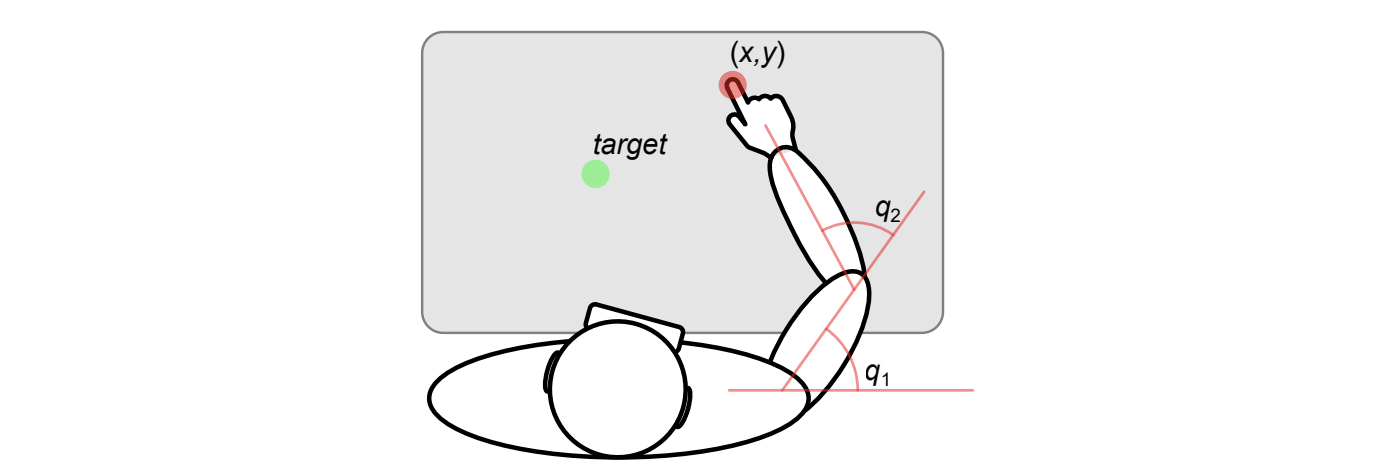


This is called a two-joint planar arm model, where we represent a user (*an Agent*) with state variables representing shoulder and elbow angular positions and velocities.

Two key components determine how the Agent move:
* An Unscented Kalman Filter (UKF) for state inference.
* A Linear Quadratic Regulator (LQR) for motor control.

At each time step (which we set to be 10 ms), the Agent
1. Predicts its current state based on the previous time step's states and the motor commands, since the Agent is prevented from having access to the true state. This will serve as the prior.
2. Updates its state estimate based on the latest sensory feedback and the prior using Bayesian inference.
3. Computes the motor commands to move the hand towards the target.

The overall idea can be summarized using the following figure.

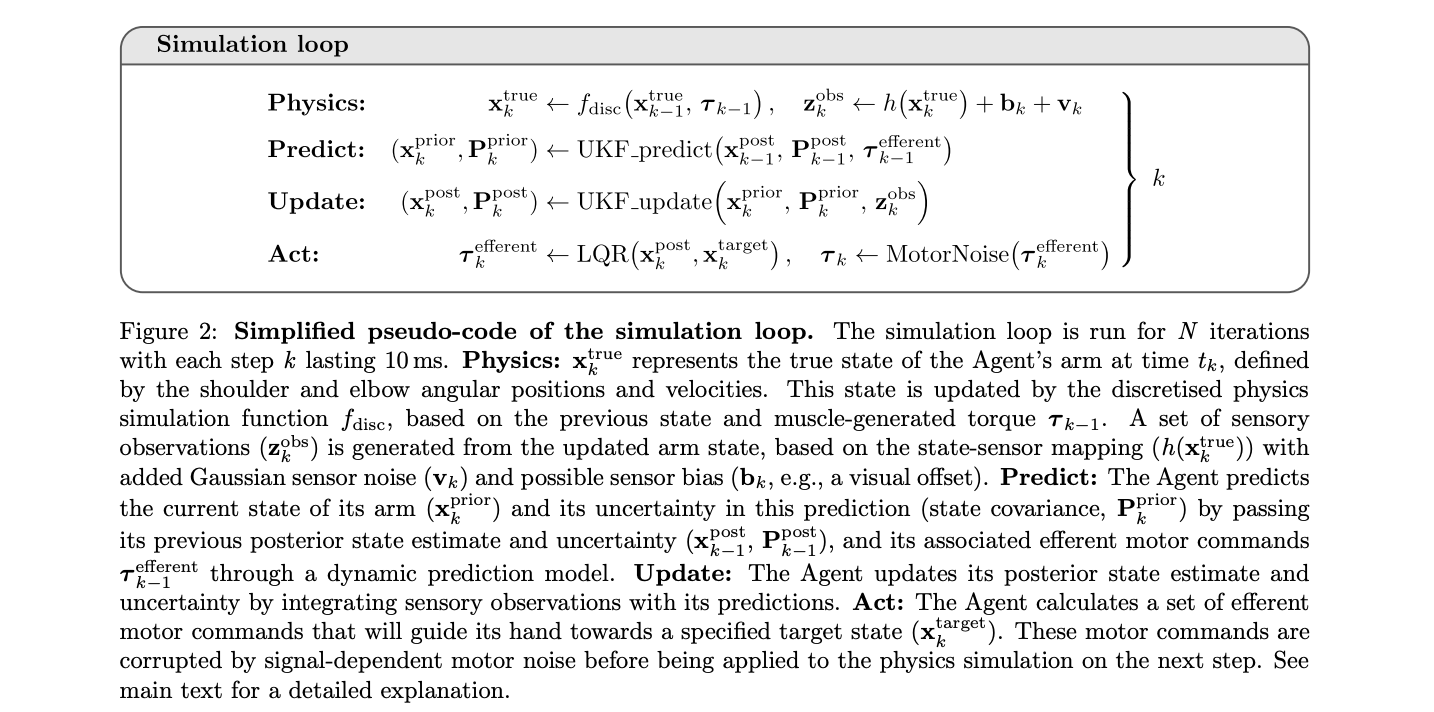


You can find much more information in [the paper](https://www.biorxiv.org/content/10.64898/2025.12.30.696730v3.full.pdf). You are not expected to read the paper in this course, and we encourage you to move on as long as you have a high-level idea of how the agent works.

⏰ As noted in the figure above, there are all kinds of noises in this process. We can adjust the noise parameters to make the agent more susceptible to specific noises. For instance, we can increase the noise in the visual perception to simulate effects like blur. Visual feedback may not always be available or may be modified by VR techniques. In Part 3, we will go through some of these examples.

## Part 2 - Simulations 🧠

### Example 1 - What if the interaction techniques manipulates feedback?

Models interaction scenarios where the cursor position does not match the true hand position:
  - Rotation: cursor moves at an angle relative to hand direction
    (e.g., rotated display, unusual tablet-to-screen mapping, prism adaptation)

`visual_intervention_bool=True` enables the distortion pipeline. `visual_feedback_rotation` sets the cursor rotation in degrees — five levels are tested: 0° (no distortion), ±10°, ±20°.

In [ ]:
b_runs.start('batches_simple_reaching_task_visual_distortion')

### Example 2 - What if vision is temporarily unavailable?

Models interaction scenarios where the cursor is visible for only part of the movement:
  - mouse moving out of the display area / off-screen
  - cursor temporarily occluded by a UI element
  - gaze-contingent display that hides the cursor after initial movement

`visual_feedback_on`: [start, end] in seconds defines the window during which the cursor is visible. With a 2-second planned movement:
  - [0, 0.4] → cursor visible for the first 20% of the movement
  - [0, 0.8] → first 40%
  - [0, 1.2] → first 60%
  - [0, 1.6] → first 80% (disappears near endpoint)
  - [0, 2.0] → full movement (equivalent to baseline)

In [ ]:
b_runs.start('batches_simple_reaching_task_intermittent_feedback')

### Example 3 - What if feedback is unreliable?

Models interaction scenarios where the cursor position is imprecise or jittery:
  - Low-resolution display or tracking system
  - High-latency rendering causing perceived cursor jitter
  - Bluetooth/wireless input device with packet loss
  - Low-fidelity AR/VR hand tracking

`vis_p_sigma` is in m/√s; the agent converts it to per-sample noise via `vis_p_sigma / sqrt(dt)`. With `dt=0.01`:
  - 0.001 → ~0.01 m per sample (baseline, high-fidelity)
  - 0.005 → ~0.05 m per sample (moderate jitter)
  - 0.010 → ~0.10 m per sample (noticeable degradation)
  - 0.020 → ~0.20 m per sample (severely degraded)
  - 0.050 → ~0.50 m per sample (nearly unusable)


In [ ]:
b_runs.start('batches_simple_reaching_task_visual_noise')

## Part 3 - Building your own simulations
As you can see from the previous parts, we can modify parameters in the Agent to simulate the consequences of varying sensory information on interactive movements.

Think of an interaction relevant to your own research. Try to flesh out: What sensory modalities are involved? For each, how does sensory information vary in the three parameters?
- Transformation: What information is transformed?
- Availability: When is information unavailable?
- Uncertainty: When does information become less reliable?

Can you build your own simulations based on the model?

⭐ You are welcome to explore the advanced batches that are included in the project to explore alternative task forms, such as a circular tracking task and a sequential reaching task.

In [ ]:
# Your own code